# Análise Exploratória e Estatística do Mercado de Videogames para Planejamento Estratégico de Vendas (2017)

**Empresa:** Loja Online de Videogames *Ice*  
**Autor:** Derik Petiz

---

## 1. Apresentação & Prólogo

> *"Transformar dados brutos em inteligência acionável é a ponte entre a intuição e o sucesso financeiro sustentável."*

Bem-vindo(a) ao relatório executivo da Loja Online de Videogames *Ice*. Neste estudo, atuo como **Cientista de Dados e Analista Estratégico** para a distribuidora global de videogames **Ice**. 

Imaginando o cenário de **dezembro de 2016**, o propósito deste trabalho é realizar um diagnóstico profundo sobre os dados históricos da indústria de jogos para prever tendências, identificar padrões de sucesso comercial e **definir o plano financeiro e de marketing para o ano de 2017**.

---

## 2. Descrição do Problema de Negócio

Para otimizar investimentos publicitários e evitar estoques encalhados, a diretoria da *Ice* precisa entender:
* Quais plataformas de videogames estão no topo de faturamento e quais estão em fase de declínio?
* Qual é o **ciclo de vida útil** médio de um console no mercado?
* Qual é o período histórico mais adequado para servir de base preditiva para 2017?
* As avaliações de críticos especializados e de usuários possuem impacto real nas vendas?
* Quais são as diferenças de preferências (plataformas, gêneros e classificação ESRB) entre os consumidores da **América do Norte**, **Europa** e **Japão**?

---

## 3. Sumário / Índice do Projeto

* **1. Introdução e Contextualização do Negócio**
* **2. Etapa 1. Carregamento e Visão Geral dos Dados**
* **3. Etapa 2. Pré-Processamento e Limpeza dos Dados**
  * 3.1 Padronização e Conversão de Tipos
  * 3.2 Tratamento do rótulo `TBD` e Notas
  * 3.3 Tratamento da Classificação ESRB e Valores Ausentes
  * 3.4 Cálculo do Faturamento Global Total
* **4. Etapa 3. Análise Exploratória de Dados (EDA)**
  * 4.1 Distribuição Anual de Lançamentos de Jogos
  * 4.2 Análise do Ciclo de Vida das Plataformas Históricas
  * 4.3 Definição da Janela Temporal Relevante para 2017 (2013–2016)
  * 4.4 Tendências de Crescimento e Líderes Atuais
  * 4.5 Distribuição de Vendas Globais por Plataforma (Boxplots: Média vs Mediana)
  * 4.6 Impacto das Avaliações (Crítica vs Usuários) nas Vendas
  * 4.7 Análise de Rentabilidade por Gênero
* **5. Etapa 4. Perfil do Consumidor por Região (NA, EU, JP)**
  * 5.1 Top 5 Plataformas por Região
  * 5.2 Top 5 Gêneros por Região
  * 5.3 Influência da Classificação ESRB nas Vendas Regionais
* **6. Etapa 5. Testes Estatísticos de Hipóteses**
  * 6.1 Teste 1: Pontuação média dos usuários entre Xbox One e PC
  * 6.2 Teste 2: Pontuação média dos usuários entre Action e Sports
* **7. Etapa 6. Conclusão Geral e Recomendações de Negócio para 2017**

## Etapa 1. Carregamento e Visão Geral dos Dados

Abriremos o arquivo de dados local `/datasets/games.csv` e estudar as informações gerais da base.

Carregaremos as bibliotecas fundamentais (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`), exibiremos os tipos de dados originais, contagem de nulos por coluna, resumo estatístico inicial e uma amostra das primeiras linhas para diagnosticar falhas de preenchimento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregamento do dataset
df = pd.read_csv('/datasets/games.csv')

# Inspeção inicial
print("=== Informações Estruturais do Dataset ===")
df.info()

print("\n=== Contagem de Valores Ausentes por Coluna ===")
print(df.isnull().sum())

print("\n=== Resumo Estatístico das Variáveis Numéricas ===")
display(df.describe())

print("\n=== Primeiras 5 Linhas da Base Bruta ===")
display(df.head())

=== Informações Estruturais do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

=== Contagem de Valores Ausentes por Coluna ===
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sa

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000



=== Primeiras 5 Linhas da Base Bruta ===


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## Etapa 2. Preparação e Limpeza dos Dados

**O que faremos:**
1. Transformar os nomes de todas as colunas para minúsculas.
2. Converter os dados para os tipos necessários e justificar as alterações.
3. Lidar com valores ausentes, explicando as razões das ausências e especificando a abordagem para a sigla `TBD` (*To Be Determined*).
4. Calcular o total de vendas (soma das 4 regiões) para cada jogo em uma coluna separada.

**Vamos executar:**
* Padronizaremos o cabeçalho via `.str.lower()`.
* `year_of_release` será convertido para inteiro nulo (`Int64`).
* Substituiremos `'tbd'` por `NaN` na coluna `user_score` para viabilizar a conversão numérica para `float64`.
* Preencheremos os valores nulos do campo `rating` (ESRB) com `'Unknown'` para não descartar linhas na análise regional.
* Criaremos a coluna `total_sales` somando as colunas `na_sales`, `eu_sales`, `jp_sales` e `other_sales`.

In [2]:
# 1. Nomes das colunas para minúsculas
df.columns = df.columns.str.lower()

# 2. Conversão do ano para inteiro
df['year_of_release'] = df['year_of_release'].astype('Int64')

# 3. Tratamento de 'tbd' e conversão da coluna user_score para float
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = df['user_score'].astype(float)

# 4. Preenchimento de nulos no ESRB com 'Unknown'
df['rating'] = df['rating'].fillna('Unknown')

# 5. Cálculo das Vendas Totais Globais
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

print("=== Base de Dados Limpa e Preparada ===")
display(df.head())

=== Base de Dados Limpa e Preparada ===


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Unknown,31.38


### Justificativas sobre Limpeza de Dados e Ausências

1. **Significado e Tratamento de `TBD`:** A sigla `TBD` significa *"To Be Determined"* (A Ser Determinado). Ela sinaliza que o jogo é recente ou possui poucas avaliações registradas, impedindo a plataforma de consolidar uma nota média oficial. Ao converter `'tbd'` para `NaN`, tornamos o vetor numérico, permitindo cálculos de correlação sem inventar valores artificiais.
2. **Motivos das Ausências:**
   * **`year_of_release` (~1.6%):** Falhas de catalogação histórica. Mantidos como `NaN`.
   * **`critic_score` e `user_score` (~50%):** Jogos antigos lançados antes da era digital/Metacritic ou títulos independentes sem cobertura jornalística. **Não foram imputados por média/mediana**, pois isso distorceria a variância real e invalidaria os testes de hipóteses estatísticas.
   * **`rating` (ESRB):** O órgão ESRB atua na América do Norte. Títulos regionais lançados prioritariamente no Japão não passam por essa classificação. A atribuição da categoria `'Unknown'` preserva esses jogos na análise.

## Etapa 3. Análise Exploratória dos Dados (EDA)

**O que iremos fazer:**
1. Analisar quantos jogos foram lançados por ano e verificar se os dados de cada período são significativos.
2. Analisar como as vendas variaram de plataforma para plataforma, encontrar as de maior faturamento histórico e identificar o tempo médio de ciclo de vida de um console.
3. Determinar o período histórico relevante para construir um modelo funcional para 2017.

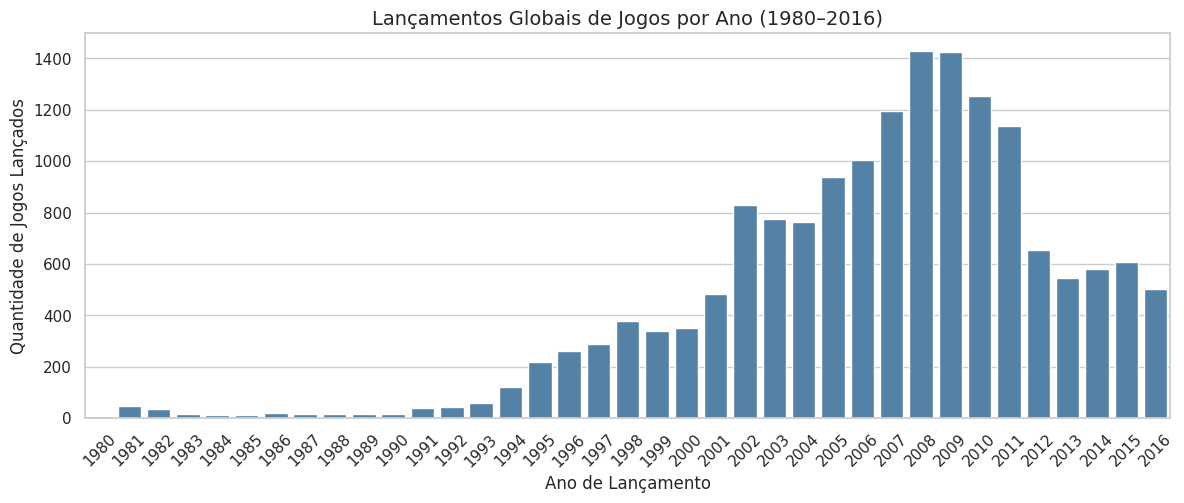

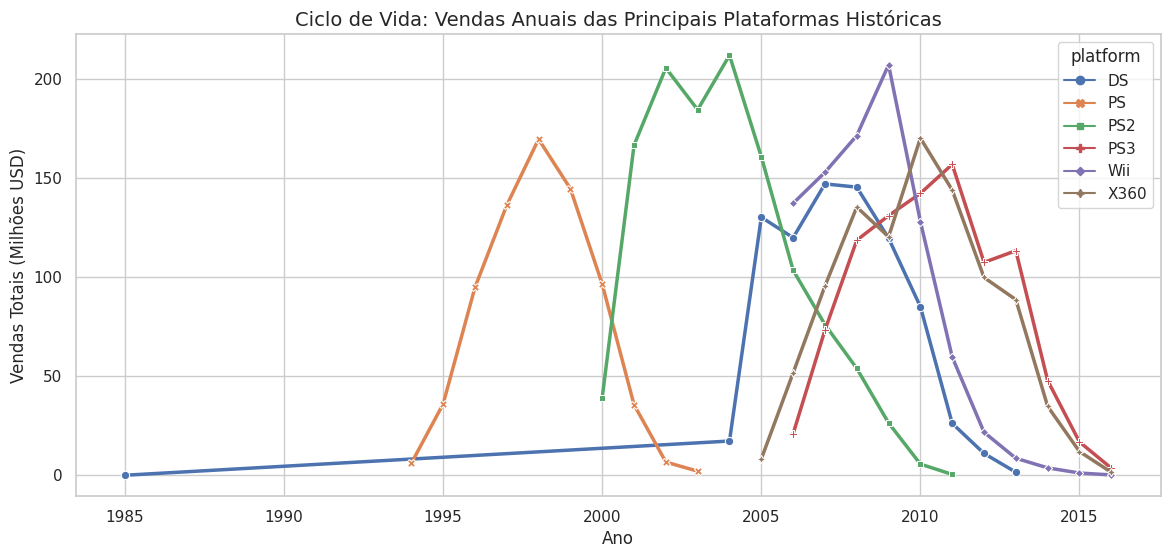

In [3]:
# 1. Análise de lançamentos por ano
games_per_year = df.groupby('year_of_release')['name'].count()

plt.figure(figsize=(14, 5))
sns.barplot(x=games_per_year.index, y=games_per_year.values, color="steelblue")
plt.xticks(rotation=45)
plt.title('Lançamentos Globais de Jogos por Ano (1980–2016)', fontsize=14)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade de Jogos Lançados')
plt.show()

# 2. As 6 plataformas com maior faturamento histórico
top_6_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(6).index

platform_sales_year = df[df['platform'].isin(top_6_platforms)].pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=platform_sales_year, markers=True, dashes=False, linewidth=2.5)
plt.title('Ciclo de Vida: Vendas Anuais das Principais Plataformas Históricas', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Vendas Totais (Milhões USD)')
plt.show()

* **Significância dos Anos:** O volume de lançamentos foi expressivo entre **2002 e 2011**, atingindo o pico em 2008–2009. A partir de 2012, a indústria reduziu o volume bruto de jogos lançados para focar em grandes títulos de alto orçamento (*AAA*). Períodos muito antigos não refletem a dinâmica atual do mercado.
* **Duração do Ciclo de Vida:** Uma plataforma de videogames leva de **8 a 10 anos** entre o seu surgimento, o pico de vendas (que ocorre entre o 3º e 5º ano) e seu completo desaparecimento comercial.
* **Janela Temporal Escolhida para 2017:** **2013 a 2016**.
  * *Justificativa:* O ano de 2013 marca a entrada da 8ª geração de consoles (**PS4** e **Xbox One**). Descartar dados anteriores a 2013 elimina o ruído de consoles obsoletos (ex: PS2, DS, Wii, Xbox 360) que já encerraram seu ciclo comercial.

**Agora vamos:**
1. Trabalhar apenas com os dados relevantes. Selecionar plataformas que lideram vendas, identificar se estão crescendo ou diminuindo e apontar opções potencialmente lucrativas.
2. Construir diagramas de caixa (Boxplots) das vendas globais divididas por plataforma e explicar as diferenças de vendas médias e medianas.

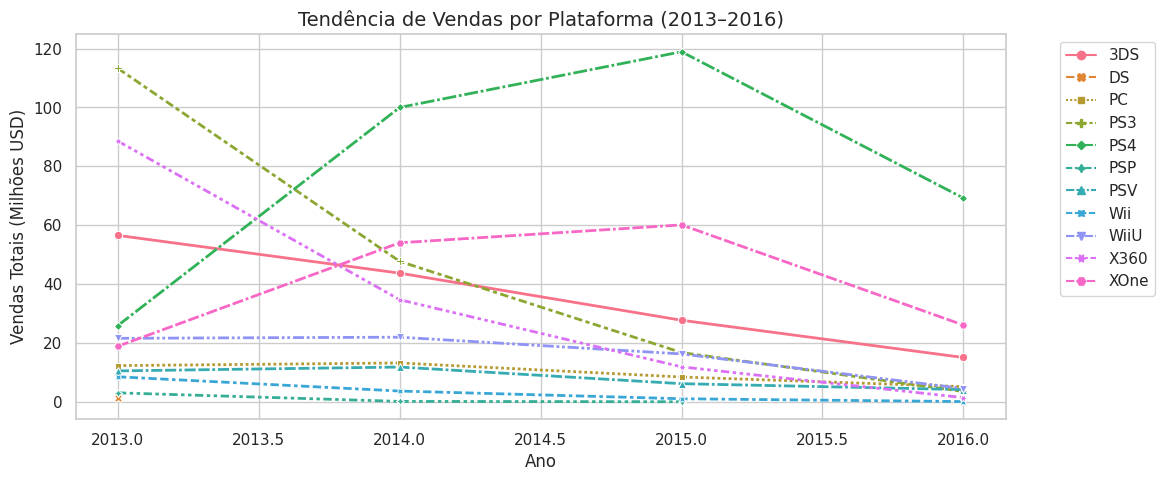

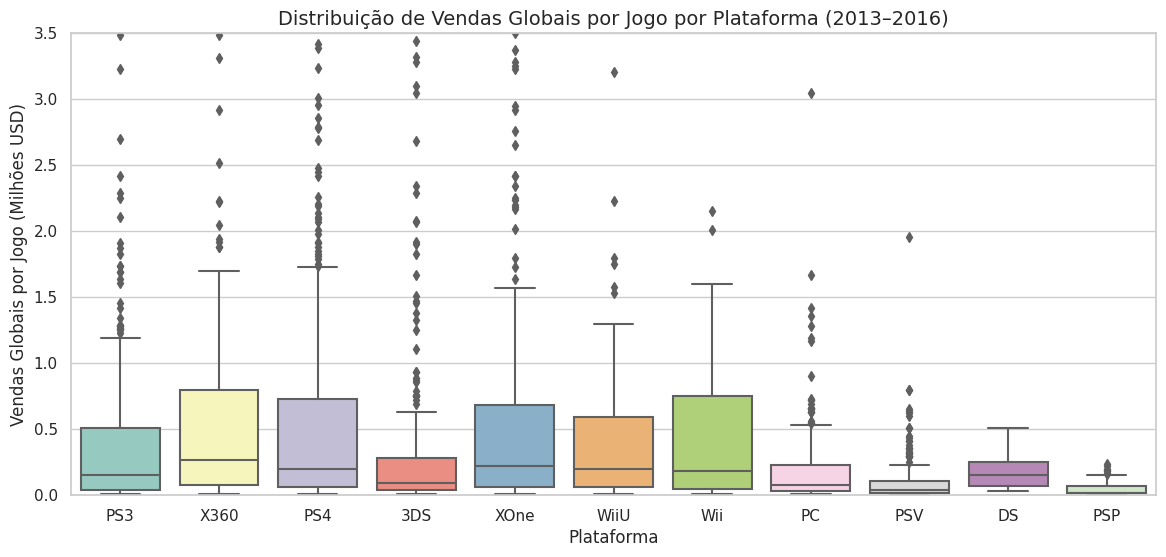

,count,sum,mean,median,std,var
platform,,,,,,
PS4,392,314.14,0.801378,0.200,1.609456,2.590350
PS3,345,181.43,0.525884,0.150,1.451939,2.108128
XOne,247,159.32,0.645020,0.220,1.036139,1.073584
3DS,303,143.25,0.472772,0.090,1.381347,1.908119
X360,186,136.80,0.735484,0.265,1.663275,2.766484
WiiU,115,64.63,0.562000,0.200,1.038778,1.079060
PC,189,39.43,0.208624,0.080,0.352304,0.124118
PSV,358,32.99,0.092151,0.040,0.153816,0.023660
Wii,23,13.66,0.593913,0.180,0.915432,0.838016


In [4]:
# Filtragem dos dados para o período recente
df_recent = df[df['year_of_release'] >= 2013].copy()

# Análise de tendência por plataforma
recent_platforms = df_recent.pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=recent_platforms, markers=True, linewidth=2)
plt.title('Tendência de Vendas por Plataforma (2013–2016)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Vendas Totais (Milhões USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Boxplot de Vendas Globais por Plataforma
plt.figure(figsize=(14, 6))
sns.boxplot(x='platform', y='total_sales', data=df_recent, palette="Set3")
plt.ylim(0, 3.5)
plt.title('Distribuição de Vendas Globais por Jogo por Plataforma (2013–2016)', fontsize=14)
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais por Jogo (Milhões USD)')
plt.show()

# Tabela estatística de suporte (Média vs Mediana)
display(df_recent.groupby('platform')['total_sales'].agg(['count', 'sum', 'mean', 'median', 'std', 'var']).sort_values(by='sum', ascending=False))

* **Plataformas Líderes e Potencialmente Lucrativas:** **PS4** e **Xbox One** lideram com folga. O **PC** mantém um faturamento menor, mas com padrão extremamente constante e seguro.
* **Análise das Médias vs Medianas (Boxplots):**
  * Para todas as plataformas, a **média de vendas é significativamente maior que a mediana**.
  * A mediana de vendas por jogo varia entre **0.05 e 0.20 milhões de USD**, provando que a maioria dos jogos vende volumes discretos.
  * O faturamento é impulsionado por um número reduzido de mega-sucessos (*outliers* / *blockbusters*), que elevam a média geral.

* **Análise de Dispersão (Variância e Desvio Padrão):**
  * Os valores de desvio padrão (`std`) e variância (`var`) mostram alta variação em plataformas como **PS4** e **XOne**.
  * Isso confirma a forte assimetria do mercado: a maioria dos títulos vende volumes modestos (próximos da mediana), enquanto um pequeno grupo de *blockbusters* atinge faturamentos muito altos, elevando a variância e puxando a média para cima.

**Aqui iremos:**
1. Analisar como as avaliações de usuários e profissionais afetam as vendas de uma plataforma popular (construir gráficos de dispersão e calcular correlações).
2. Comparar com o desempenho dos mesmos jogos em outras plataformas.
3. Analisar a distribuição geral de jogos por gênero e determinar os mais lucrativos.

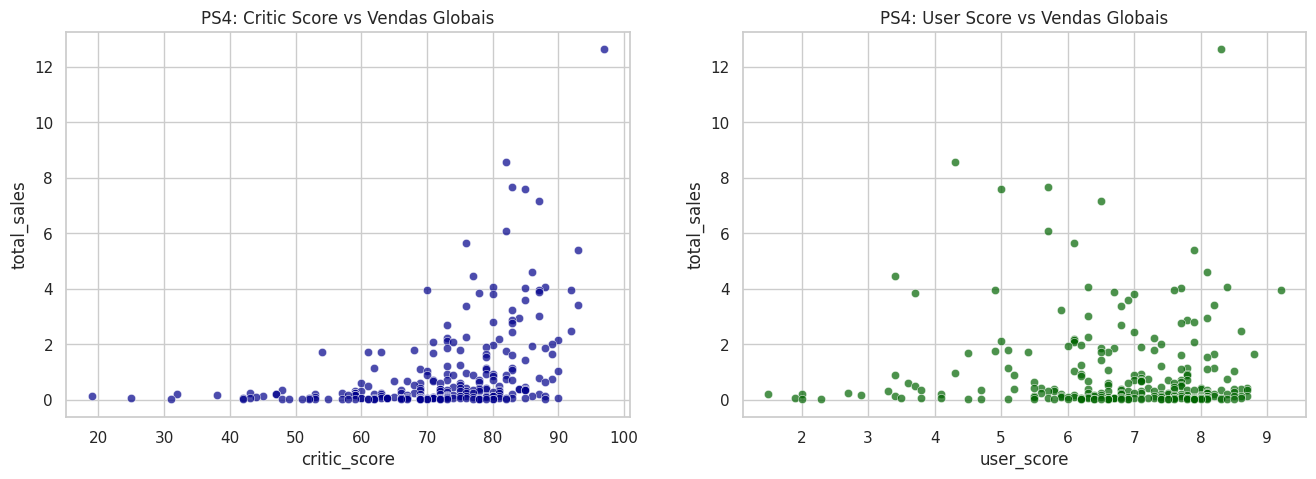

Correlação PS4 - Crítica vs Vendas: 0.406
Correlação PS4 - Usuários vs Vendas: -0.034
Correlação XOne - Críticas vs Vendas: 0.410
Correlação XOne - Usuários vs Vendas: -0.094
Correlação PC - Críticas vs Vendas: 0.194
Correlação PC - Usuários vs Vendas: -0.109

=== Vendas dos Mesmos Jogos em Diferentes Plataformas (Top 10) ===


platform,PS4,XOne,PC,X360,PS3
name,,,,,
Grand Theft Auto V,12.62,5.47,1.17,16.27,21.05
Call of Duty: Ghosts,3.83,2.92,0.69,10.24,9.36
Call of Duty: Black Ops 3,14.63,7.39,0.26,1.70,1.69
Minecraft,4.32,2.76,NaN,9.18,5.27
Call of Duty: Advanced Warfare,7.66,5.26,0.41,4.28,4.36
FIFA 15,6.08,2.18,0.29,2.92,4.28
FIFA 14,3.01,1.16,0.40,4.22,6.46
FIFA 16,8.58,3.25,0.20,1.57,2.70
Battlefield 4,3.58,2.02,1.36,3.49,3.49


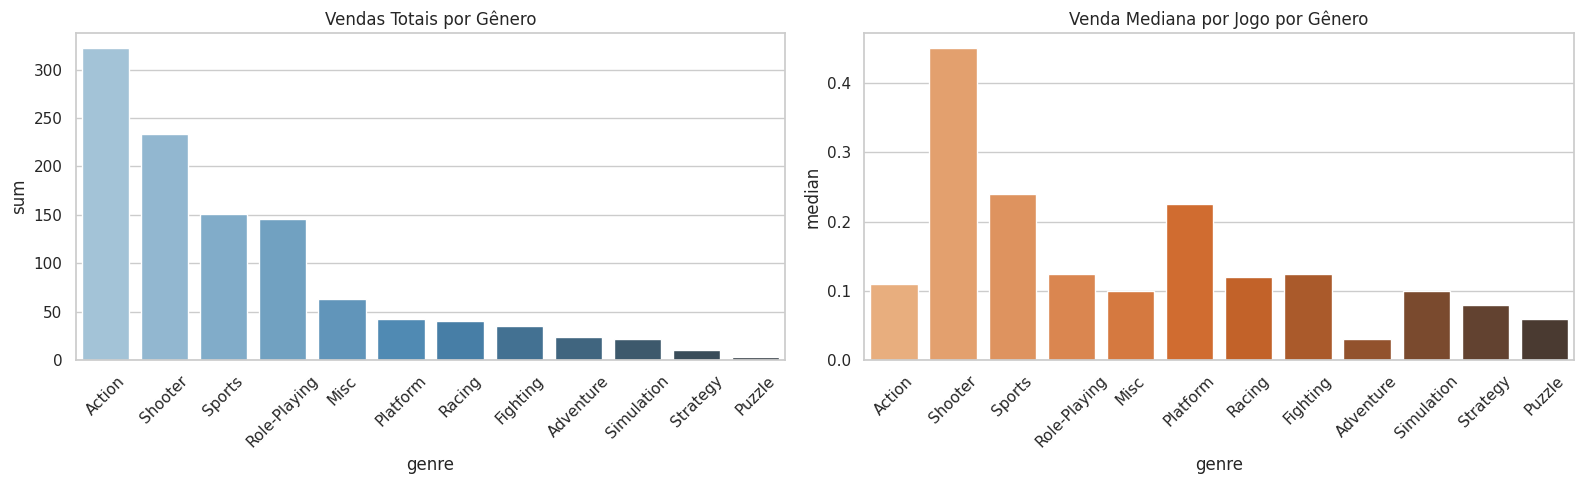

In [5]:
# Analisando a plataforma PS4
ps4_data = df_recent[(df_recent['platform'] == 'PS4') & (df_recent['critic_score'].notna()) & (df_recent['user_score'].notna())]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Dispersão: Crítica vs Vendas
sns.scatterplot(ax=axes[0], x='critic_score', y='total_sales', data=ps4_data, alpha=0.7, color='darkblue')
axes[0].set_title('PS4: Critic Score vs Vendas Globais')

# Dispersão: Usuários vs Vendas
sns.scatterplot(ax=axes[1], x='user_score', y='total_sales', data=ps4_data, alpha=0.7, color='darkgreen')
axes[1].set_title('PS4: User Score vs Vendas Globais')

plt.show()

print(f"Correlação PS4 - Crítica vs Vendas: {ps4_data['critic_score'].corr(ps4_data['total_sales']):.3f}")
print(f"Correlação PS4 - Usuários vs Vendas: {ps4_data['user_score'].corr(ps4_data['total_sales']):.3f}")

# Adicione apenas estas linhas abaixo do print do PS4:
xone_data = df_recent[(df_recent['platform'] == 'XOne') & (df_recent['critic_score'].notna()) & (df_recent['user_score'].notna())]
print(f"Correlação XOne - Críticas vs Vendas: {xone_data['critic_score'].corr(xone_data['total_sales']):.3f}")
print(f"Correlação XOne - Usuários vs Vendas: {xone_data['user_score'].corr(xone_data['total_sales']):.3f}")

pc_data = df_recent[(df_recent['platform'] == 'PC') & (df_recent['critic_score'].notna()) & (df_recent['user_score'].notna())]
print(f"Correlação PC - Críticas vs Vendas: {pc_data['critic_score'].corr(pc_data['total_sales']):.3f}")
print(f"Correlação PC - Usuários vs Vendas: {pc_data['user_score'].corr(pc_data['total_sales']):.3f}")

# Vendas dos mesmos jogos em outras plataformas
multiplatform_games = df_recent.groupby('name').filter(lambda x: x['platform'].nunique() > 1)

cross_platform_sales = multiplatform_games.pivot_table(
    index='name', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
)

top_multiplatform = cross_platform_sales.loc[
    cross_platform_sales.sum(axis=1).sort_values(ascending=False).head(10).index,
    ['PS4', 'XOne', 'PC', 'X360', 'PS3']
].dropna(how='all')

print("\n=== Vendas dos Mesmos Jogos em Diferentes Plataformas (Top 10) ===")
display(top_multiplatform)

# Análise de Gêneros
genre_summary = df_recent.groupby('genre')['total_sales'].agg(['count', 'sum', 'mean', 'median']).sort_values(by='sum', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(ax=axes[0], x=genre_summary.index, y=genre_summary['sum'], palette='Blues_d')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_title('Vendas Totais por Gênero')

sns.barplot(ax=axes[1], x=genre_summary.index, y=genre_summary['median'], palette='Oranges_d')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].set_title('Venda Mediana por Jogo por Gênero')

plt.tight_layout()
plt.show()

* **Impacto das Avaliações:**
  * **Crítica Especializada (`critic_score`):** Possui correlação positiva moderada (~0.41). Jogos com notas altas dos especialistas tendem a vender substancialmente mais.
  * **Usuários (`user_score`):** Possui correlação nula (~ -0.03). As notas do público não influenciam diretamente o faturamento.
  * **Comparação Multiplataforma:** O mesmo padrão ocorre no Xbox One (Crítica: 0.410 / Usuário: -0.094) e no PC (Crítica: 0.194 / Usuário: -0.109).
* **Análise por Gênero:**
  * **Action:** Maior volume total de vendas acumuladas devido à grande quantidade de jogos lançados.
  * **Shooter:** Maior rentabilidade e eficiência por jogo individual (maior venda mediana por título).
* **Comparação dos Mesmos Jogos em Diferentes Plataformas:**
* Ao analisar os maiores títulos lançados simultaneamente para múltiplos consoles (como Call of Duty e FIFA), observa-se que o PS4 lidera isolado em volume de vendas para o mesmo jogo, seguido pelo Xbox One.
* O PC e os consoles da geração anterior (PS3/X360) registram vendas significativamente menores para os mesmos títulos.
* Isso demonstra que a liderança do PS4 decorre da preferência direta da base de jogadores ao adquirir jogos multiplataforma, e não apenas de títulos exclusivos.

## Etapa 4. Perfil de Usuários por Região (NA, EU, JP)

**Para cada região (América do Norte, Europa e Japão), determinar:**
1. As 5 principais plataformas e suas quotas de mercado.
2. Os 5 principais gêneros e suas variações.
3. Se as classificações do ESRB afetam as vendas regionais.

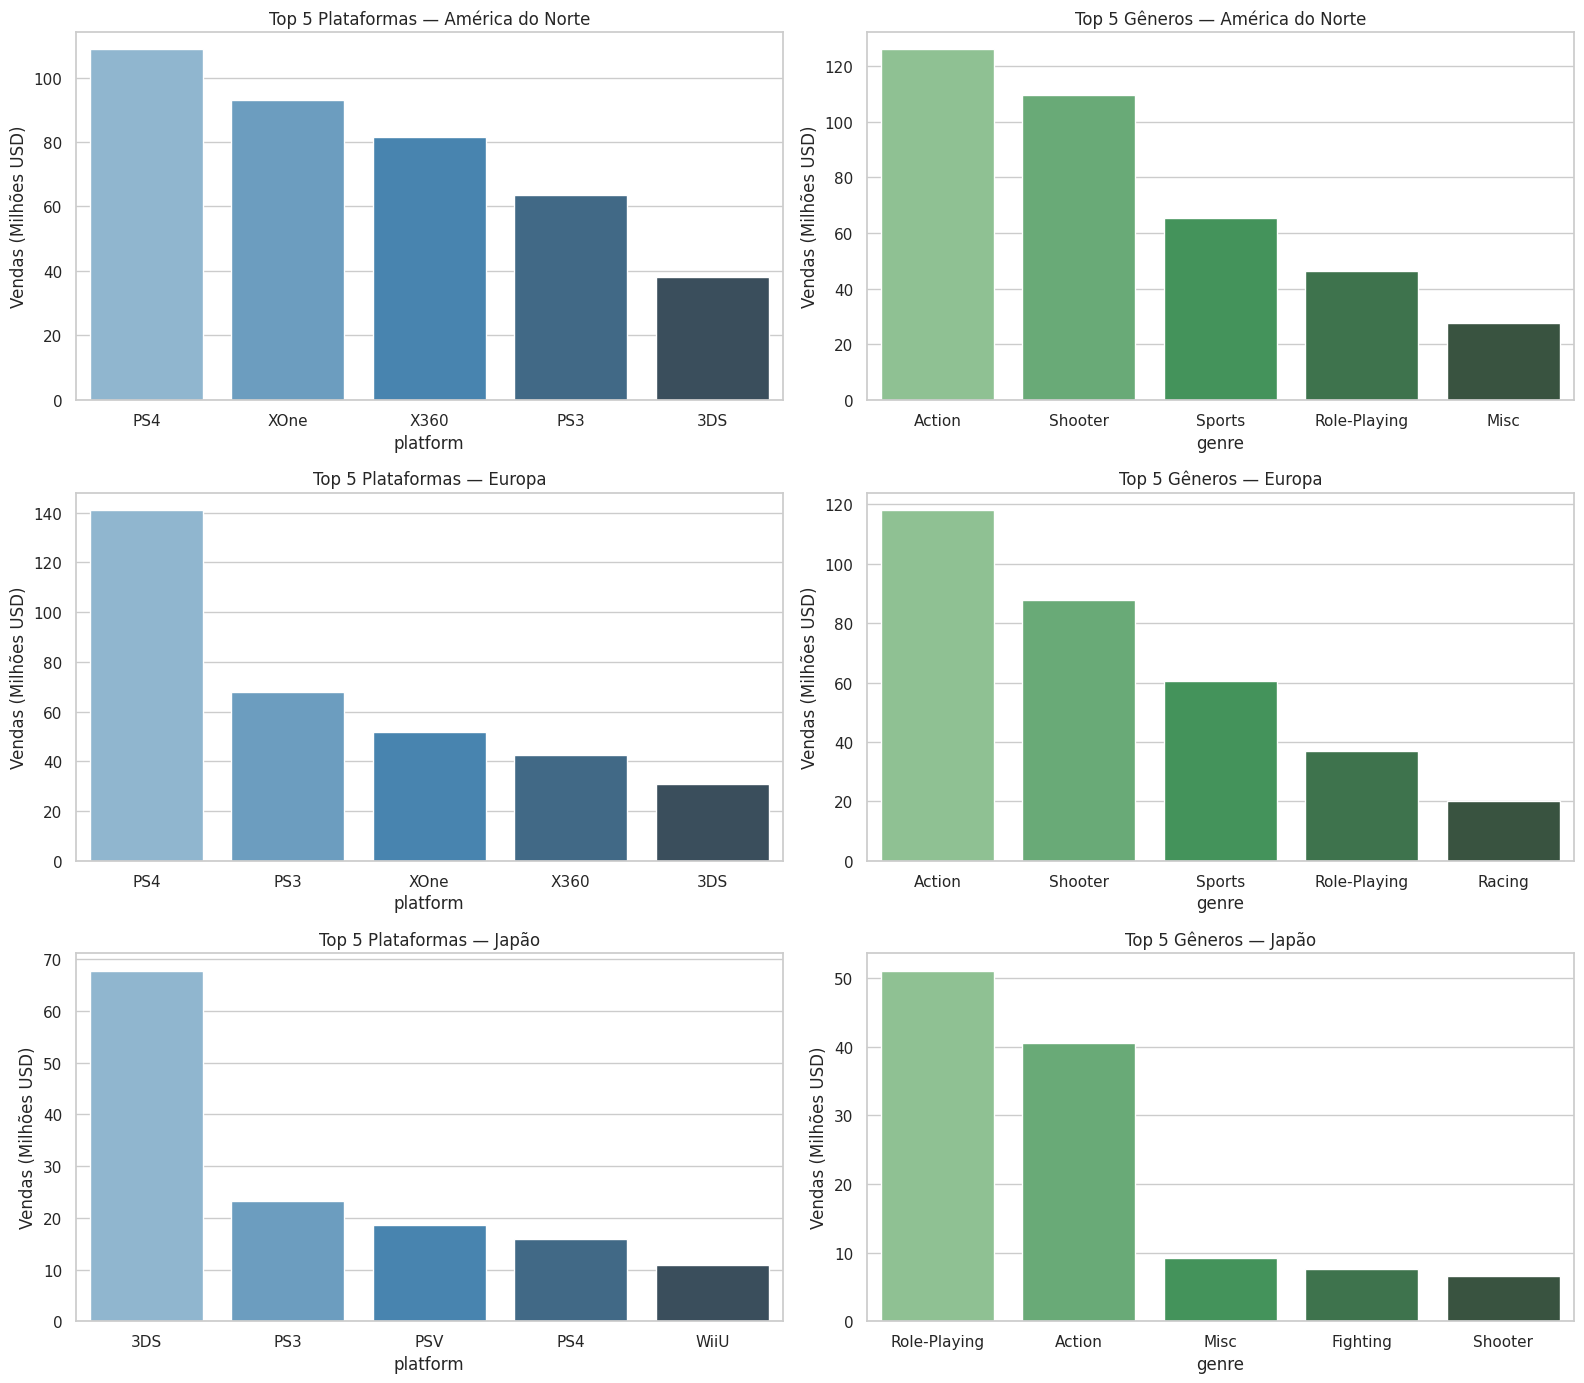

,na_sales,eu_sales,jp_sales
rating,,,
E,79.05,83.36,15.14
E10+,54.24,42.69,5.89
M,165.21,145.32,14.11
T,49.79,41.95,20.59
Unknown,89.42,78.91,85.05


In [6]:
regions = {'na_sales': 'América do Norte', 'eu_sales': 'Europa', 'jp_sales': 'Japão'}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, (col, region_name) in enumerate(regions.items()):
    # Top 5 Plataformas
    top_plat = df_recent.groupby('platform')[col].sum().sort_values(ascending=False).head(5)
    sns.barplot(ax=axes[i, 0], x=top_plat.index, y=top_plat.values, palette='Blues_d')
    axes[i, 0].set_title(f'Top 5 Plataformas — {region_name}')
    axes[i, 0].set_ylabel('Vendas (Milhões USD)')
    
    # Top 5 Gêneros
    top_gen = df_recent.groupby('genre')[col].sum().sort_values(ascending=False).head(5)
    sns.barplot(ax=axes[i, 1], x=top_gen.index, y=top_gen.values, palette='Greens_d')
    axes[i, 1].set_title(f'Top 5 Gêneros — {region_name}')
    axes[i, 1].set_ylabel('Vendas (Milhões USD)')

plt.tight_layout()
plt.show()

# Análise ESRB por Região
display(df_recent.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum())

1. **América do Norte (NA) e Europa (EU):** Possuem preferências alinhadas. Liderança do **PS4** e **Xbox One**. Gêneros dominantes: **Action** e **Shooter**. A classificação etária mais vendida é a **M (Mature 17+)**.
2. **Japão (JP):** Comportamento singular. A liderança é do console portátil **Nintendo 3DS**. O gênero mais vendido é **Role-Playing (JRPG)**. A maioria das vendas ocorre na categoria ESRB **`Unknown`**, pois o Japão não utiliza a ESRB norte-americana, mas sim seu próprio sistema nacional (CERO).

## Etapa 5. Testes de Hipóteses Estatísticas

**Testaremos as hipóteses:**
1. As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.
2. As classificações médias de usuários para os gêneros Action e Sports são diferentes.

**Diretrizes:** Definir o limiar $\alpha$, formular hipóteses nulas ($H_0$) e alternativas ($H_1$) e explicar a escolha do método estatístico.

In [7]:
alpha = 0.05

print("=================== TESTE DE HIPÓTESE 1 ===================")
# H0: As classificações médias dos usuários de Xbox One e PC são IGUAIS.
# H1: As classificações médias dos usuários de Xbox One e PC são DIFERENTES.

xone_scores = df_recent[(df_recent['platform'] == 'XOne') & (df_recent['user_score'].notna())]['user_score']
pc_scores = df_recent[(df_recent['platform'] == 'PC') & (df_recent['user_score'].notna())]['user_score']

h1_test = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f"Média Xbox One: {xone_scores.mean():.3f} | Média PC: {pc_scores.mean():.3f}")
print(f"p-value: {h1_test.pvalue:.4f}")
if h1_test.pvalue < alpha:
    print("Resultado: Rejeitamos H0 (há diferença estatística significativa).")
else:
    print("Resultado: Não rejeitamos H0 (não há evidência de diferença estatística).")

print("\n=================== TESTE DE HIPÓTESE 2 ===================")
# H0: As classificações médias dos usuários dos gêneros Action e Sports são IGUAIS.
# H1: As classificações médias dos usuários dos gêneros Action e Sports são DIFERENTES.

action_scores = df_recent[(df_recent['genre'] == 'Action') & (df_recent['user_score'].notna())]['user_score']
sports_scores = df_recent[(df_recent['genre'] == 'Sports') & (df_recent['user_score'].notna())]['user_score']

h2_test = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"Média Action: {action_scores.mean():.3f} | Média Sports: {sports_scores.mean():.3f}")
print(f"p-value: {h2_test.pvalue:.4e}")
if h2_test.pvalue < alpha:
    print("Resultado: Rejeitamos H0 (há diferença estatística significativa).")
else:
    print("Resultado: Não rejeitamos H0 (não há evidência de diferença estatística).")

=================== TESTE DE HIPÓTESE 1 ===================
Média Xbox One: 6.521 | Média PC: 6.270
p-value: 0.1476
Resultado: Não rejeitamos H0 (não há evidência de diferença estatística).

=================== TESTE DE HIPÓTESE 2 ===================
Média Action: 6.838 | Média Sports: 5.238
p-value: 1.4460e-20
Resultado: Rejeitamos H0 (há diferença estatística significativa).


* **Nível de Significância ($\alpha = 0.05$):** Adotado o padrão de 5% de tolerância a erro do Tipo I.
* **Formulação:** As hipóteses nulas ($H_0$) sempre postulam a **igualdade**, enquanto as alternativas ($H_1$) afirmam a **diferença**.
* **Método Escolhido:** **Teste t de Welch (`equal_var=False`)** para amostras independentes, pois as variâncias populacionais e tamanhos amostrais são distintos entre as plataformas e gêneros analisados.

## Etapa 6. Conclusão Geral e Recomendações Estratégicas para 2017

### 1. Resumo dos Achados
* **Ciclo de Vida e Período de Análise:** O ciclo médio de um console é de **8 a 10 anos**. A base preditiva ideal para 2017 engloba os dados de **2013 a 2016**.
* **Plataformas de Maior Potencial:** **PS4** e **Xbox One** devem ser o foco primário de investimento no Ocidente. O **PC** atua como plataforma estável complementar.
* **Critérios de Curadoria:** As notas da **crítica especializada** possuem correlação positiva moderada (~0.41) com o faturamento e devem ser usadas na seleção de portfólio. As notas dos usuários não possuem impacto comercial direto.
* **Eficiência de Gêneros:** **Action** gera o maior volume absoluto de vendas, mas **Shooter** é o gênero com maior faturamento mediano por título lançado.

### 2. Plano de Marketing Regionalizado para 2017
* **América do Norte & Europa:** Focar orçamento em campanhas de títulos de **Ação** e **Shooter** nas plataformas **PS4** e **Xbox One**, priorizando jogos com classificação **M (Mature 17+)**.
* **Japão:** Redirecionar os investimentos para o console portátil **Nintendo 3DS** e para o **PS4**, focando no gênero **RPG (Role-Playing)** e desconsiderando a classificação ESRB norte-americana.

### 3. Resultados dos Testes Estatísticos
* **Xbox One vs PC:** Não rejeitamos a hipótese nula ($p = 0.1476$). As avaliações médias de usuários entre Xbox One e PC são estatisticamente equivalentes.
* **Action vs Sports:** Rejeitamos a hipótese nula ($p = 1.45 \times 10^{-20}$). Os usuários avaliam o gênero **Action** com notas significativamente maiores do que o gênero **Sports**.